# Prototype

## Channel Model – Key Relations

$th(x) = gpc \left( 1 - \exp(-c Q(x) t_p) \right)$  

$Q(x) = Q_0 \exp(-x/x_s)$  

$x_s \propto \sqrt{T/p_A}$

In [1]:
import torch
import torch.nn as nn

from torchdiffeq import odeint
import matplotlib.pyplot as plt

In [2]:
import numpy as np
import matplotlib.pyplot as plt

N0 = 6.22*10**23
k = 1.38*10**-23 # Boltzmann constant
R = 8.314 # J/K.mol

T = 300 + 273 # Temperature
M = 101.96/1000 # kg/mol (molar mass)
gpc = 106 * 10**-12 # gpc (m)

c = 0.01 # c = sticking probability
Pd = 0 # Pd = Desorption probability

Pa = 100#*1e-3 # Partial Pressure of reactant A (limiting diffusion)
Pb = 300 # partial pressure of reactant B

rho = 3.99*1000 #density of film material
t_p = 0.1 #pulse time
K = 100 # equilibrium constant for langmuir model

q = (2/1) * (rho*gpc/M) * N0 #TMA q (adsorption density)
Q = N0/np.sqrt(2*np.pi* M * R * T)# Q = collisons/unit pressure

# Channel Geometry
H = 0.5e-6
W = 0.1e-3

h = 2/(1/H + 1/W)

# Molar Mass
MA = 72.09e-3 #kg/mol
MB = 18e-3


In [3]:
#may be better fitting the 'd' values
def d_estimate(MA, rho):
    #rho here is the fluid/solid density of the molecule
    return 2* np.pow(3*MA/(4*np.pi*rho*N0), 1/3)

def za(da, db, MA, MB, pA, pB):
    #find collision rate of a; (A+B) collisions and A+A collisions
    #molecular diameter, molar mass, partial pressure
    return (np.pi/4*((da+db)**2)*np.sqrt(8*R*T/np.pi*(1/MA + 1/MB)) * pB + np.pi * da**2 * np.sqrt(16*R*T/(np.pi*MA))*pA) /(R*T)

def Deff(da, db, MA, MB, pA, pB):
    z_a = za(da, db, MA, MB, pA, pB)
    va = np.sqrt(8*R*T/(np.pi * MA))
    Da = 3*np.pi/16 * va**2/z_a
    Dkn = h*np.sqrt(8*R*T/(9*np.pi*MA))
    Deff = 1/(1/Da + 1/Dkn)
    return Deff

# Channel approximation

In [4]:
def approx(x, t, Deff, pA0, last_theta):
    D = pA0*Deff*H/(q*k*T*(1-np.log(K*pA0+1)/(K*pA0)))
    xs = np.sqrt(D*t)
    delim = np.sqrt((h*N0*Deff)/(4*R*T*c*Q))
    xt = xs-delim#np.max(0.0, xs-delim)
    if xt < 0:
        xt = 0
    pt = pA0*(1-xt/xs)
    pA = pA0 * (1-x/xs)
    pA[x>xt] = pt*np.exp(-(x[x>xt]-xt)/(xs-xt))

    theta = (K*pA)/(1+K*pA)

    next_theta = last_theta + theta

    thickness = gpc*next_theta

    #print('xt: ', xt)

    return thickness, next_theta, {'theta':theta, 'pA': pA}

In [5]:
da = 591e-12 #tma #d_estimate()
db = 418e-12 #water #d_estimate()

Deff_step = Deff(da, db, MA, MB, pA=Pa, pB=Pb)

x = np.linspace(0, 200e-6, 100)
last_theta = np.zeros_like(x)
for i in range(100):
    result = approx(x, t=t_p, Deff=Deff_step, pA0=Pa, last_theta = last_theta)
    last_theta = result[1]
result_0 = np.copy(result[0])
for i in range(1000):
    result = approx(x, t=t_p, Deff=Deff_step, pA0=Pa, last_theta = last_theta)
    last_theta = result[1]
result_1 = np.copy(result[0])

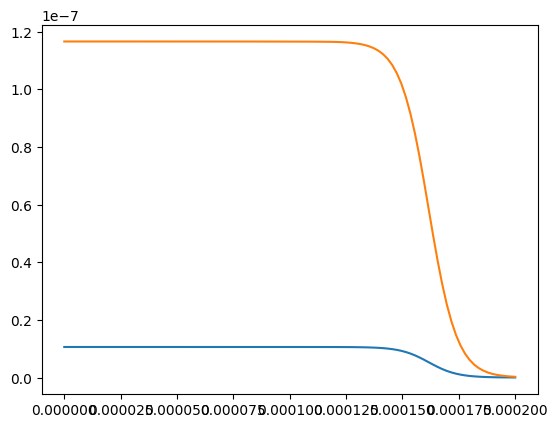

In [6]:
plt.plot(x, result_0)
plt.plot(x, result_1)

## Hexagonal model

Text(0, 0.5, 'Thickness (nm)')

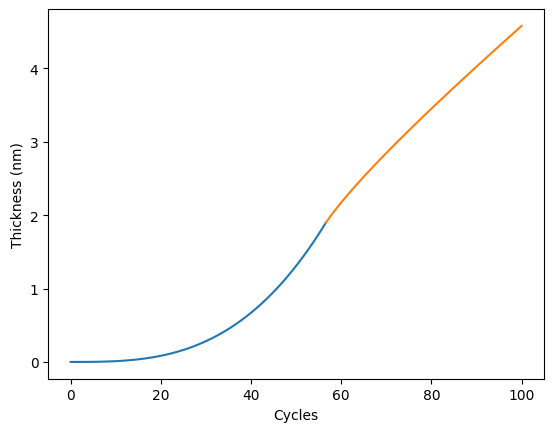

In [7]:
Nd = 0.04
t = np.linspace(0, 100, 100)
r = t*0.05
Rcov = 1/np.sqrt(np.pi * Nd)
tcut = np.sum(r<Rcov)
plt.plot(t[:tcut+1], 2/3 *np.pi*Nd*(r[:tcut+1])**3)

t2 = t[tcut:]
r = r[tcut:]
plt.plot(t2, Nd * (np.pi*(Rcov**2)*np.sqrt(r**2 - Rcov**2)+np.pi/6*(3*Rcov**2+(r-np.sqrt(r**2-Rcov**2))**2)*(r-np.sqrt(r**2-Rcov**2))))
plt.xlabel('Cycles')
plt.ylabel('Thickness (nm)')

In [8]:
import numpy as np
from scipy.integrate import quad

Gr = .1 # growth rate
vd = 0 # the characteristic number of cycles for nucleation incubation
Nn = .001 # density of initial nucleation sites
Nr0 = 0 # nucleation site generation rate
A0 = 100

def Aenx_1(v):
    return np.exp(-vd/v)*(n-v)**2
# def Aenx_2_a(v):
#     return np.exp(-vd/v)*((n-v)**2)
def Aenx_2b(v):
    return np.exp(-vd/v)

#t = torch.linspace(0,20,100)
#out = odeint(Aenx_1, torch.Tensor([n]), t)

P1 = []
P2 = []

for n in np.arange(400):
    #Aenx_1_  = quad(Aenx_1, 1e-6, n)[0]
    #Aenx_2_  = quad(Aenx_2b, 1e-6, n)[0] #quad(lambda v: Aenx_2(v, (h/Gr)**2), 1e-6, n)[0]

    Aenx1 = lambda dn: A0 * np.pi * Gr**2 * Nr0 * quad(lambda v: np.exp(-vd/v)*(dn-v)**2, 1e-6, dn)[0] #simple version
    Aenx2 = lambda h: A0 * np.pi * Gr**2 * Nr0 * (quad(Aenx_1, 1e-6, n-h/Gr)[0]-(h/Gr)**2*quad(Aenx_2b, 1e-6, n-h/Gr)[0]) #complex version

    Aenn1 = lambda dn: A0 * np.pi * (Gr*dn)**2 * Nn
    Aenn2 = lambda h: A0 * np.pi * ((Gr*n)**2-h**2) * Nn

    Aen1 = lambda dn: Aenx1(dn)+Aenn1(dn)
    Aen2 = lambda h: Aenx2(h)+Aenn2(h)

    Af1 = lambda dn: A0*(1-np.exp(-Aen1(dn)/A0))
    Af2 = lambda h: A0 * (1 - np.exp(-Aen2(h)/A0))

    Vf1 = quad(lambda dn: (2-Af1(dn)/A0)*Af1(dn)*Gr, 1e-6, n)[0]
    Vf2 = quad(Af2, 1e-6, Gr*n)[0]

    tf1 = Vf1/A0
    tf2 = Vf2/A0

    P1.append(tf1)
    P2.append(tf2)


In [9]:
import matplotlib.pyplot as plt

Text(0, 0.5, 'Thickness (nm)')

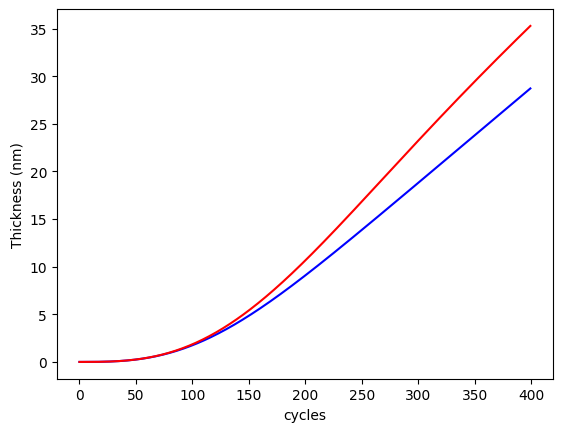

In [10]:
#plt.plot(np.arange(len(Points)), 1-np.exp(-np.array(Points)/A0))
plt.plot(np.arange(len(P1)), P1, color='blue')
plt.plot(np.arange(len(P2)), P2, color='red')
plt.xlabel('cycles')
plt.ylabel('Thickness (nm)')

# Streamlined Model Design

## Pure Model Function

### Hex Model

In [11]:
# Nd = 0.04
# t = np.linspace(0, 100, 100)
# r = t*0.05
# Rcov = 1/np.sqrt(np.pi * Nd)
# tcut = np.sum(r<Rcov)
# plt.plot(t[:tcut+1], 2/3 *np.pi*Nd*(r[:tcut+1])**3)

# t2 = t[tcut:]
# r = r[tcut:]
# plt.plot(t2, Nd * (np.pi*(Rcov**2)*np.sqrt(r**2 - Rcov**2)+np.pi/6*(3*Rcov**2+(r-np.sqrt(r**2-Rcov**2))**2)*(r-np.sqrt(r**2-Rcov**2))))
# plt.xlabel('Cycles')
# plt.ylabel('Thickness (nm)')

In [12]:
import numpy as np

def hex_model(cycle, Nd = 0.04, delta_r=0.05):
    #t = np.linspace(0, 100, 100)
    cycle = np.array(cycle)
    radius = cycle*delta_r
    Rcov = 1/np.sqrt(np.pi * Nd)
    #tcut = np.sum(r<Rcov)
    result = np.zeros_like(cycle)
    lower = lambda r: 2/3 *np.pi*Nd*(r[r < Rcov])**3
    upper = lambda r: Nd * (np.pi*(Rcov**2)*np.sqrt((r)**2 - Rcov**2)+np.pi/6*(3*Rcov**2+(r-np.sqrt(r**2-Rcov**2))**2)*(r-np.sqrt(r**2-Rcov**2)))

    result[radius < Rcov] = lower(radius[radius < Rcov])
    result[radius >= Rcov] = upper(radius[radius >= Rcov])

    return result

### Avrami Model

In [13]:
import numpy as np
from scipy.integrate import quad

# def Aenx_1(v):
#     return np.exp(-vd/v)*(n-v)**2
# def Aenx_2b(v):
#     return np.exp(-vd/v)

lower_limit = 1

def avrami_model(cycle,
                Gr = .1, # growth rate
                vd = 0, # the characteristic number of cycles for nucleation incubation
                Nn = .001, # density of initial nucleation sites
                Nr0 = 0, # nucleation site generation rate
                A0 = 100 # substrate area
                ):

    res = []
    cycle = np.array(cycle)
    for n in cycle:
        def Aenx_1(v):
            return np.exp(-vd/v)*(n-v)**2
        def Aenx_2b(v):
            return np.exp(-vd/v)
        Aenx1 = lambda dn: A0 * np.pi * Gr**2 * Nr0 * quad(lambda v: np.exp(-vd/v)*(dn-v)**2, lower_limit, dn)[0] #simple version

        Aenn1 = lambda dn: A0 * np.pi * (Gr*dn)**2 * Nn

        Aen1 = lambda dn: Aenx1(dn)+Aenn1(dn)

        Af1 = lambda dn: A0*(1-np.exp(-Aen1(dn)/A0))

        Vf1 = quad(lambda dn: (2-Af1(dn)/A0)*Af1(dn)*Gr, lower_limit, n)[0]

        tf1 = Vf1/A0

        res.append(tf1)

    return res

def avrami_model_2(cycle,
                    Gr = .1, # growth rate
                    vd = 0, # the characteristic number of cycles for nucleation incubation
                    Nn = .001, # density of initial nucleation sites
                    Nr0 = 0, # nucleation site generation rate
                    A0 = 100 # substrate area
                    ):


    res = []
    cycle = np.array(cycle)
    for n in cycle:
        #n = cycle
        def Aenx_1(v):
            return np.exp(-vd/v)*(n-v)**2
        def Aenx_2b(v):
            return np.exp(-vd/v)
        Aenx2 = lambda h: A0 * np.pi * Gr**2 * Nr0 * (quad(Aenx_1, lower_limit, n-h/Gr)[0]-(h/Gr)**2*quad(Aenx_2b, lower_limit, n-h/Gr)[0]) #complex version

        Aenn2 = lambda h: A0 * np.pi * ((Gr*n)**2-h**2) * Nn

        Aen2 = lambda h: Aenx2(h)+Aenn2(h)

        Af2 = lambda h: A0 * (1 - np.exp(-Aen2(h)/A0))

        Vf2 = quad(Af2, lower_limit, Gr*n)[0]

        tf2 = Vf2/A0

        res.append(tf2)

    return res



### Model Parameter Fit

In [14]:
from scipy.optimize import curve_fit
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd

## Channel Profile

In [15]:
import numpy as np
import matplotlib.pyplot as plt
import pandas as pd

In [16]:
N0 = 6.22*10**23
k = 1.38*10**-23 # Boltzmann constant
R = 8.314 # J/K.mol

In [17]:
# #may be better fitting the 'd' values
# def d_estimate(MA, rho):
#     #rho here is the fluid/solid density of the molecule
#     return 2* np.pow(3*MA/(4*np.pi*rho*N0), 1/3)

# def za(da, db, MA, MB, pA, pB):
#     #find collision rate of a; (A+B) collisions and A+A collisions
#     #molecular diameter, molar mass, partial pressure
#     return (np.pi/4*((da+db)**2)*np.sqrt(8*R*T/np.pi*(1/MA + 1/MB)) * pB + np.pi * da**2 * np.sqrt(16*R*T/(np.pi*MA))*pA) /(R*T)

# def Deff(da, db, MA, MB, pA, pB):
#     z_a = za(da, db, MA, MB, pA, pB)
#     va = np.sqrt(8*R*T/(np.pi * MA))
#     Da = 3*np.pi/16 * va**2/z_a
#     Dkn = h*np.sqrt(8*R*T/(9*np.pi*MA))
#     Deff = 1/(1/Da + 1/Dkn)
#     return Deff

In [18]:
class channelModel():

    def __init__(self):

        self.M = 101.96/1000 # kg/mol (molar mass of formula unit of film)
        self.rho = 3.99*1000 #density of film material

        self.b_film = 2 # number of metal atoms in the formula unit for the film
        self.b_a = 1 # number of metal atoms in the reactant, i.e. TMA
        self.c = 0.01 # c = sticking probability
        #self.Pd = 0 # Pd = Desorption probability
        self.da = 591e-12 #tma #d_estimate()
        self.db = 418e-12 #water #d_estimate()
        # Molar Mass
        self.MA = 72.09e-3 #kg/mol
        self.MB = 18e-3

        # Channel Geometry
        self.H = 0.2e-6
        self.W = 0.1e-3

        self.gpc = 106 * 10**-12 # gpc (m)
        self.K = 100 # equilibrium constant for langmuir model
        # or K = cQ/(qP_d)
        # But they seem to generally give K as its own value
        # c is used for calculating the delimiter instead

        self.T = 300 + 273 # Temperature
        self.t_p = 0.1 #pulse time

        self.pA = 100 #*1e-3 # Partial Pressure of reactant A (limiting diffusion)
        #self.pA0 = self.pA
        self.pB = 300 # partial pressure of reactant B

    def calc_hydro_diameter(self):
        self.h = 2/(1/self.H + 1/self.W)
    def calc_adsorption_density(self):
        self.q = (self.b_film/self.b_a) * (self.rho*self.gpc/self.M) * N0 #TMA q (adsorption density)
    def collision_rate(self):
        self.Q = N0/np.sqrt(2*np.pi* self.M * R * self.T)# Q: collision rate at unit pressure

    def calc_za(self):
        #find collision rate of a; (A+B) collisions and A+A collisions
        #molecular diameter, molar mass, partial pressure
        self.za = (np.pi/4*((self.da+self.db)**2)*np.sqrt(8*R*self.T/np.pi*(1/self.MA + 1/self.MB)) * self.pB + \
                   np.pi * self.da**2 * np.sqrt(16*R*self.T/(np.pi*self.MA))*self.pA) /(R*self.T)
    def calc_Deff(self):
        z_a = self.za #(self.da, self.db, self.MA, self.MB, self.pA, self.pB)
        va = np.sqrt(8*R*self.T/(np.pi * self.MA))
        Da = 3*np.pi/16 * va**2/z_a
        Dkn = self.h*np.sqrt(8*R*self.T/(9*np.pi*self.MA))
        self.Deff = 1/(1/Da + 1/Dkn)

    def approx(self, x, last_theta):

        D = self.pA*self.Deff*self.H/(self.q*k*self.T*(1-np.log(self.K*self.pA+1)/(self.K*self.pA)))
        xs = np.sqrt(D*self.t_p)
        delim = np.sqrt((self.h*N0*self.Deff)/(4*R*self.T*self.c*self.Q))
        xt = xs-delim #np.max(0.0, xs-delim)
        if xt < 0:
            xt = 0
        pt = self.pA * (1-xt/xs)
        pA = self.pA * (1-x/xs)
        pA[x>xt] = pt*np.exp(-(x[x>xt]-xt)/(xs-xt))

        theta = (self.K*pA)/(1+self.K*pA)

        next_theta = last_theta + theta

        thickness = self.gpc*next_theta

        #print('xt: ', xt)

        return thickness, next_theta, {'theta':theta, 'pA': pA}

    def run(self, steps, initial_x):

        results = []#pd.DataFrame()

        #Assuming no temperature change, these don't need recalculation
        self.collision_rate()
        self.calc_adsorption_density()
        self.calc_za()
        last_theta = initial_x.copy()

        original_H = self.H

        for step in range(steps):
            self.calc_hydro_diameter()
            self.calc_Deff()
            thickness, last_theta, intermediates = self.approx(x, last_theta)
            results.append(pd.DataFrame({'thickness': thickness} | intermediates))
            self.H = self.H - 2 * self.gpc

        self.H = original_H

        results = pd.concat(results, keys=range(steps))
        return results




In [19]:
model = channelModel()
#model.pA *= 2
model.t_p*=10
model.H = 0.5* 0.2e-6
model.W = 1000*0.2e-6

In [20]:
x = np.linspace(0, 200e-6, 100)
result = model.run(100, x)

In [21]:
#result#['thickness'].values


In [22]:
# plt.plot(x, result['thickness'][19])
# plt.plot(x, result['thickness'][39])
# plt.plot(x, result['thickness'][59])
# plt.plot(x, result['thickness'][79])
# plt.plot(x, result['thickness'][99])

# plt.plot(x, model.H-result['thickness'][19])
# plt.plot(x, model.H-result['thickness'][39])
# plt.plot(x, model.H-result['thickness'][59])
# plt.plot(x, model.H-result['thickness'][79])
# plt.plot(x, model.H-result['thickness'][99])
# plt.ticklabel_format(style='sci', axis='x', scilimits=(0,0))

Text(0, 0.5, 'channel geometry')

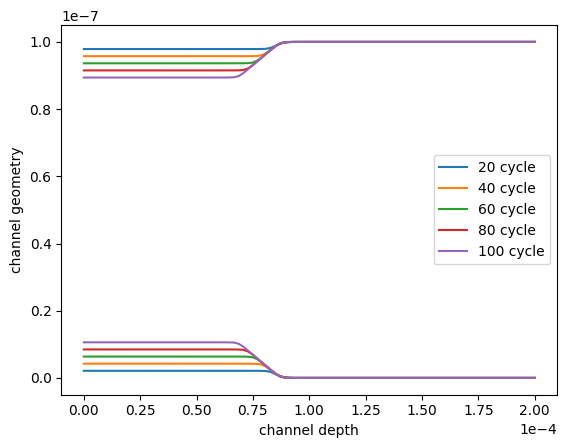

In [23]:
for cycle in [20, 40, 60, 80, 100]:
    l1 = plt.plot(x, result['thickness'][cycle-1], label= f'{cycle} cycle')
    plt.plot(x, model.H-result['thickness'][cycle-1], color=l1[0].get_color())

plt.ticklabel_format(style='sci', axis='x', scilimits=(0,0))
plt.legend()
plt.xlabel('channel depth')
plt.ylabel('channel geometry')

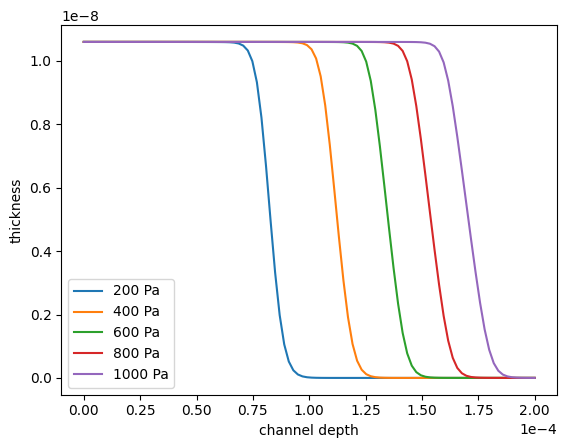

In [24]:

for pressure in range(200, 1200, 200):
    model = channelModel()
    model.pA = pressure
    x = np.linspace(0, 200e-6, 100)
    result = model.run(100, x)
    plt.plot(x, result['thickness'][99], label=f'{pressure} Pa')
plt.legend()
plt.ylabel('thickness')
plt.xlabel('channel depth')
plt.ticklabel_format(style='sci', axis='x', scilimits=(0,0))

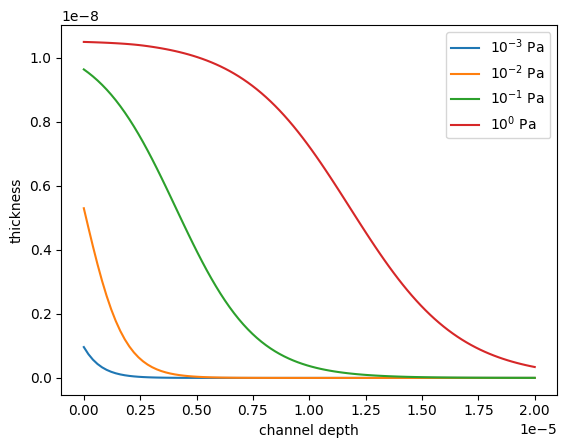

In [25]:

for pressure in range(-3, 1):
    model = channelModel()
    model.pA = 10**(pressure)
    x = np.linspace(0, 20e-6, 100)
    result = model.run(100, x)
    plt.plot(x, result['thickness'][99], label='$10^{'+f'{pressure}'+'}$ Pa')
plt.legend()
plt.ylabel('thickness')
plt.xlabel('channel depth')
plt.ticklabel_format(style='sci', axis='x', scilimits=(0,0))

Text(0.5, 0, 'channel depth')

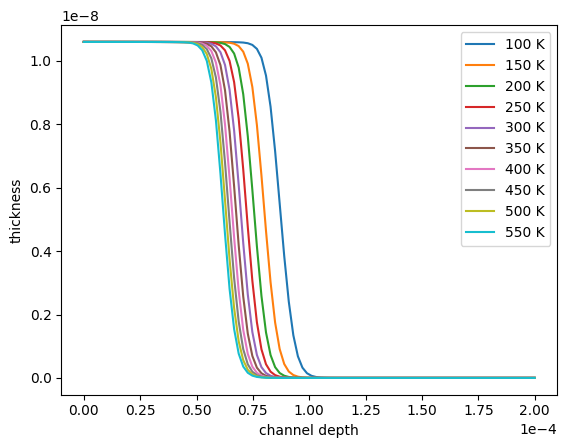

In [26]:

for temperature in range(100, 600, 50):
    model = channelModel()
    model.T = temperature
    x = np.linspace(0, 200e-6, 100)
    result = model.run(100, x)
    plt.plot(x, result['thickness'][99], label=f'{temperature} K')
plt.legend()
plt.ticklabel_format(style='sci', axis='x', scilimits=(0,0))
plt.ylabel('thickness')
plt.xlabel('channel depth')

Text(0, 0.5, 'pressure')

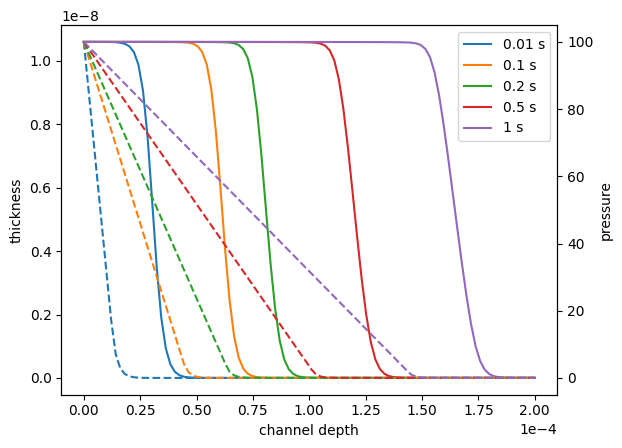

In [27]:
ax1 = plt.gca()
ax2 = ax1.twinx()

for time in [.01, .1, .2, .5, 1]:
    model = channelModel()
    model.t_p = time
    x = np.linspace(0, 200e-6, 100)
    result = model.run(100, x)
    p1 = ax1.plot(x, result['thickness'][99], label=f'{time} s')
    ax2.plot(x, result['pA'][99], color = p1[0].get_color(), linestyle='--')
ax1.legend()
plt.ticklabel_format(style='sci', axis='x', scilimits=(0,0))
ax1.set_ylabel('thickness')
ax1.set_xlabel('channel depth')
ax2.set_ylabel('pressure')

Text(0.5, 0, 'channel depth')

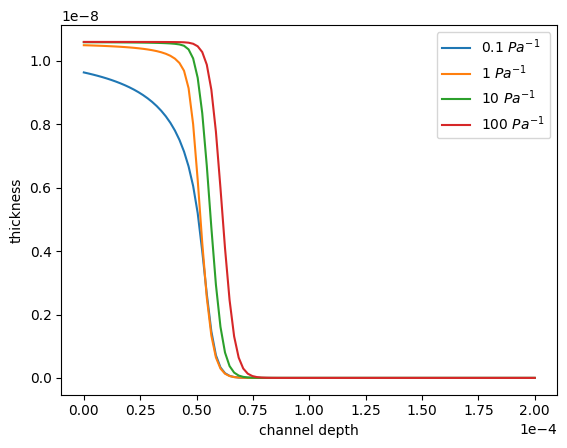

In [28]:

for ads_const in [.1, 1, 10, 100]:
    model = channelModel()
    model.K = ads_const
    x = np.linspace(0, 200e-6, 100)
    result = model.run(100, x)
    plt.plot(x, result['thickness'][99], label=f'{ads_const} '+'$Pa^{-1}$')
plt.legend()
plt.ticklabel_format(style='sci', axis='x', scilimits=(0,0))
plt.ylabel('thickness')
plt.xlabel('channel depth')